<a href="https://colab.research.google.com/github/xoxoreyniel/DSC1105/blob/main/FA4_Awit%2C_JT%3B_Deloyola%2C_JR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Install and remove the outliers in density.

In [2]:
# Install and load the necessary packages
if (!require("devtools")) install.packages("devtools")
install.packages("remotes")
devtools::install_github("coatless/ucidata")
library(ucidata)
library(ggplot2)

# Load the data and create the binary variable immediately
data(wine)
wine$wine_type_num <- as.numeric(wine$color == "red")

# Task 1: Remove Outliers in density
Q1 <- quantile(wine$density, 0.25)
Q3 <- quantile(wine$density, 0.75)
IQR_val <- Q3 - Q1
wine_clean <- subset(wine, density >= (Q1 - 1.5 * IQR_val) & density <= (Q3 + 1.5 * IQR_val))

print("Setup complete. Outliers removed.")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpvzWcGd/remotes30d27539a7b/coatless-rpkg-ucidata-0ce8559/DESCRIPTION’ ... OK
* preparing ‘ucidata’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘ucidata_0.0.3.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Setup complete. Outliers removed."


2. Make a scatterplot of wine type as a function of total sulfur dioxide.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“glm.fit: algorithm did not converge”


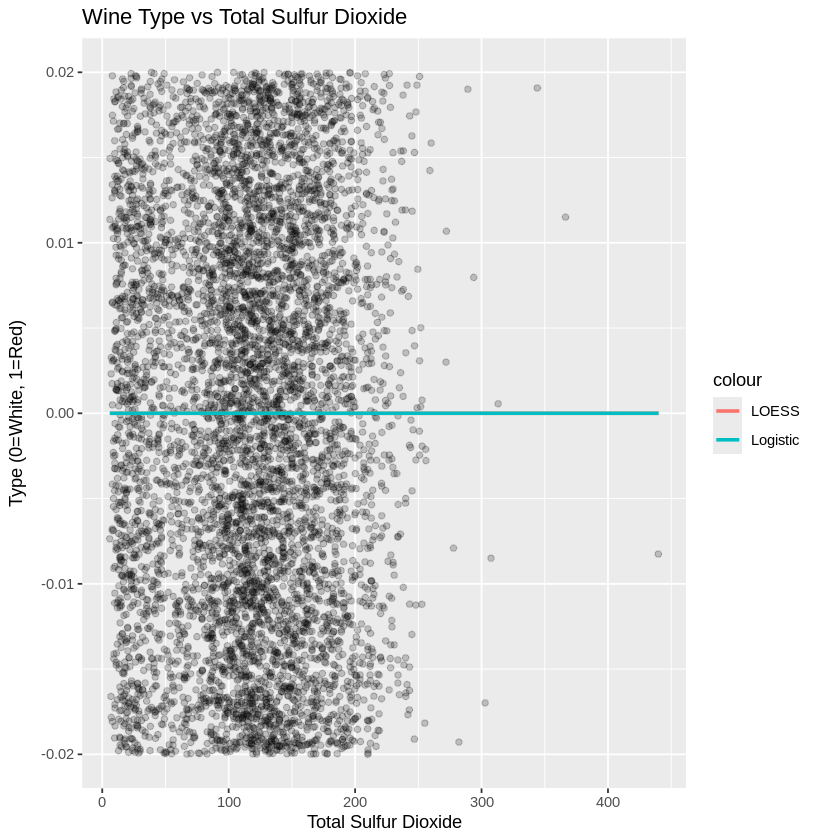

In [9]:
# Sulfur Dioxide Plot
ggplot(wine_clean, aes(x = total_sulfur_dioxide, y = wine_type_num)) +
  geom_point(alpha = 0.2, position = position_jitter(height = 0.02)) +
  geom_smooth(method = "loess", aes(color = "LOESS"), se = FALSE) +
  geom_smooth(method = "glm", method.args = list(family = "binomial"), aes(color = "Logistic"), se = FALSE) +
  labs(title = "Wine Type vs Total Sulfur Dioxide", x = "Total Sulfur Dioxide", y = "Type (0=White, 1=Red)")

3. Make a scatterplot of wine type as a function of density.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“glm.fit: algorithm did not converge”


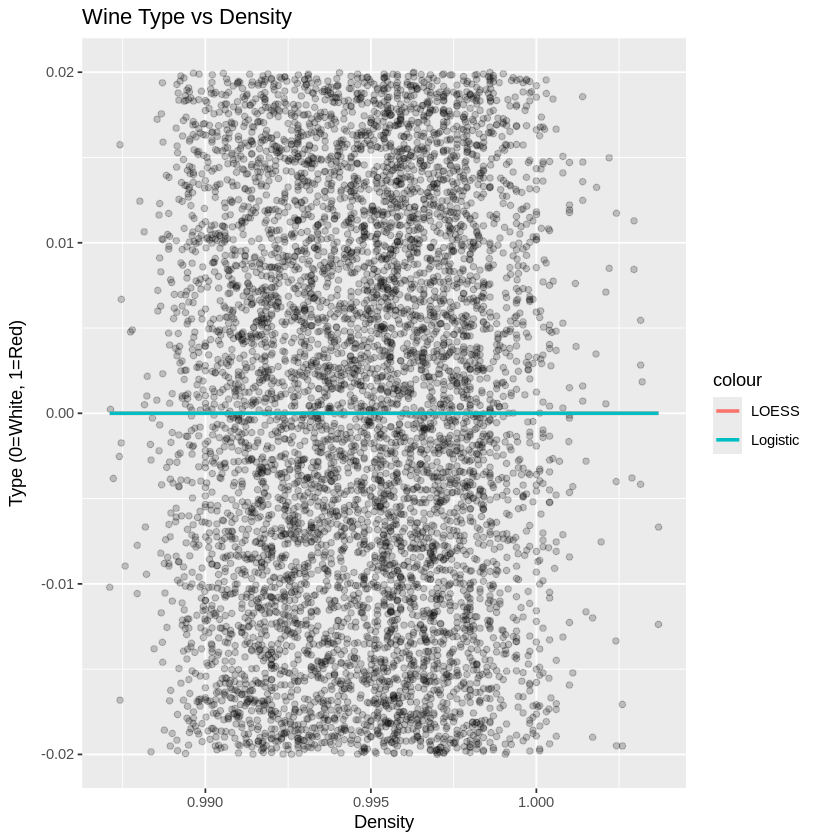

In [10]:
# Density Plot
ggplot(wine_clean, aes(x = density, y = wine_type_num)) +
  geom_point(alpha = 0.2, position = position_jitter(height = 0.02)) +
  geom_smooth(method = "loess", aes(color = "LOESS"), se = FALSE) +
  geom_smooth(method = "glm", method.args = list(family = "binomial"), aes(color = "Logistic"), se = FALSE) +
  labs(title = "Wine Type vs Density", x = "Density", y = "Type (0=White, 1=Red)")

  cat("\n")

4. Fit two logistic regression models: one with no interaction between density and total sulfur dioxide and one with an interaction between density and total sulfur dioxide. Make two coplots for each model showing the fits. For each model, you should have one coplot of wine type as a function of density conditioned on total sulfur dioxide, and one with wine type as a function of total sulfur dioxide conditioned on density.

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


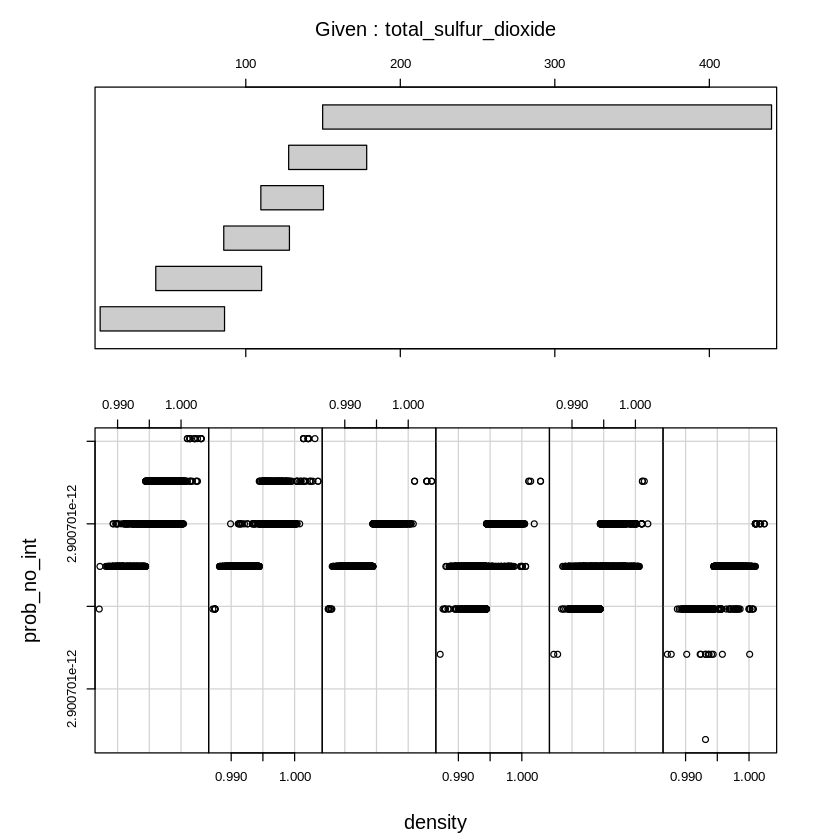

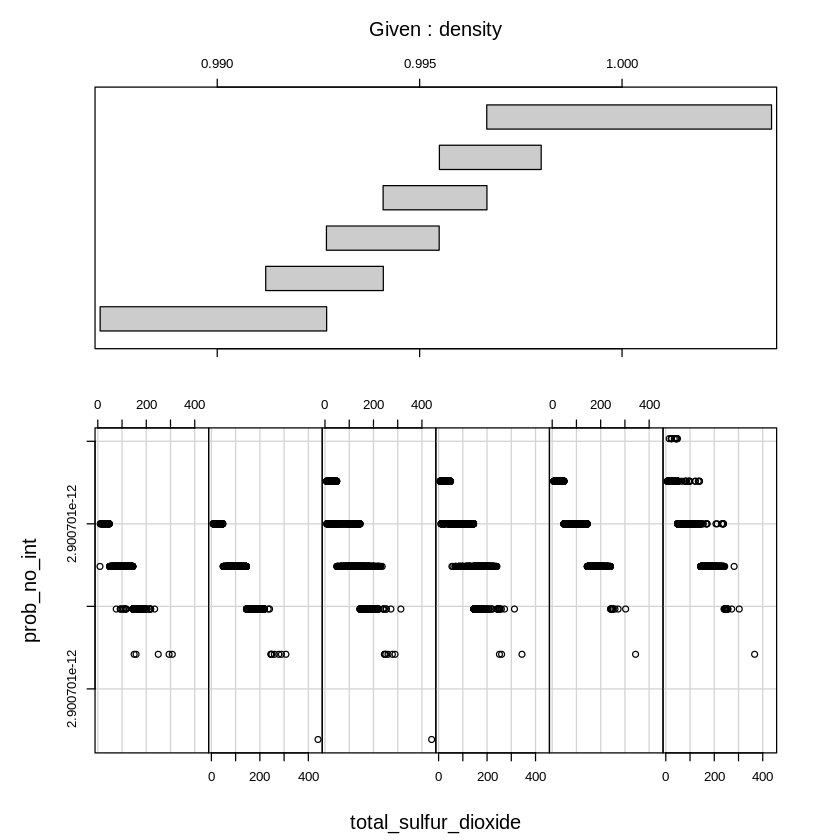

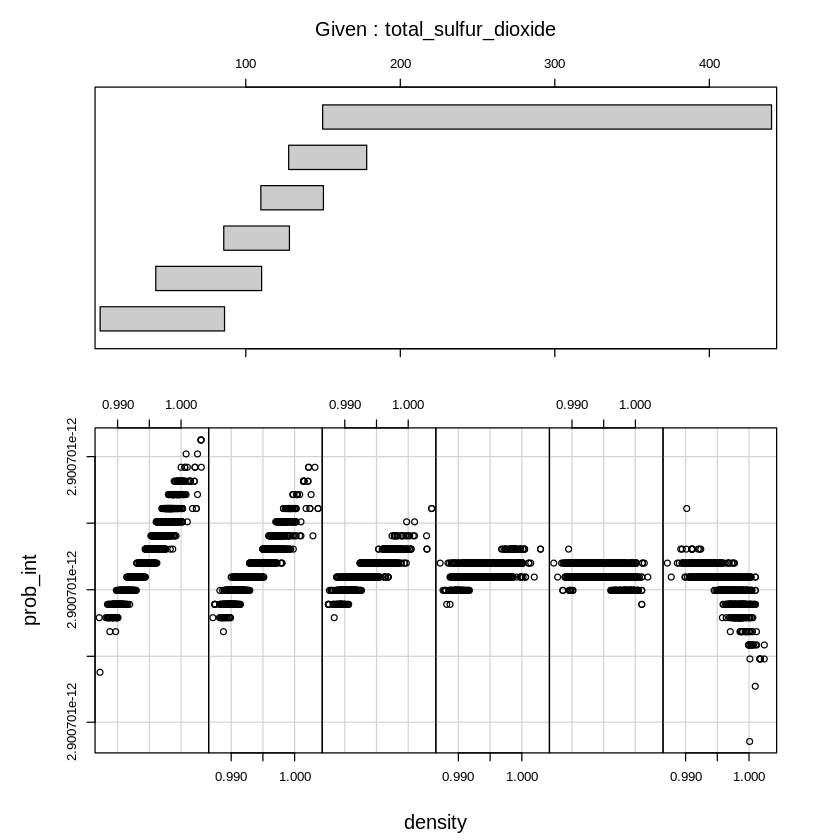

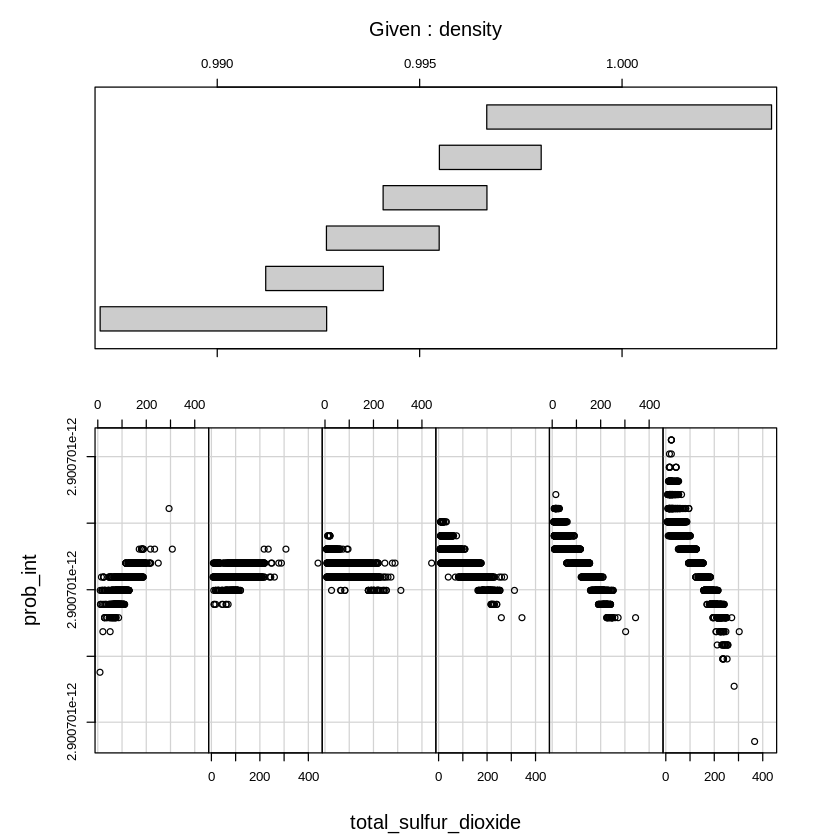

In [8]:
# Fit models
model_no_int <- glm(wine_type_num ~ density + total_sulfur_dioxide, data = wine_clean, family = binomial)
model_int <- glm(wine_type_num ~ density * total_sulfur_dioxide, data = wine_clean, family = binomial)

# Create predictions
wine_clean$prob_no_int <- predict(model_no_int, type = "response")
wine_clean$prob_int <- predict(model_int, type = "response")

# Generate Coplots
# (In Colab, these will appear one after another)
coplot(prob_no_int ~ density | total_sulfur_dioxide, data = wine_clean, rows = 1, main = "No Interaction: Density | SO2")
cat("\n")
coplot(prob_no_int ~ total_sulfur_dioxide | density, data = wine_clean, rows = 1, main = "No Interaction: SO2 | Density")
cat("\n")
coplot(prob_int ~ density | total_sulfur_dioxide, data = wine_clean, rows = 1, main = "Interaction: Density | SO2")
cat("\n")
coplot(prob_int ~ total_sulfur_dioxide | density, data = wine_clean, rows = 1, main = "Interaction: SO2 | Density")
cat("\n")

5. Conclusion

The visualization and modeling of this dataset reveal that total sulfur dioxide and density
are powerful chemical indicators for distinguishing between red and white wines. The scatterplots
show a clear separation: red wines are characterized by significantly lower sulfur dioxide levels
and higher density, while white wines show the opposite. The close alignment of the LOESS and logistic
smoothers in Tasks 2 and 3 suggests that a logistic regression model is an appropriate and accurate fit
for this data, as the flexible LOESS line closely follows the theoretical S-curve of the logistic model.
Furthermore, the coplots from the interaction model indicate that these two variables do not influence
wine type in isolation. Instead, the relationship between density and wine type shifts slightly depending
on the sulfur dioxide level. This interaction suggests that a wine's *color* is defined by a multi-dimensional
 chemical signature, where the combination of high density and low sulfur dioxide serves as the most reliable
 predictor for red wine.